# PPG-Dalia practice (feature-based baseline)

Notebook này giúp bạn thực hành với dataset **PPG-Dalia trên Kaggle**:
- Tải dataset từ Kaggle
- Khám phá cấu trúc dữ liệu
- Trích xuất feature từ PPG theo cửa sổ thời gian
- Train baseline model và đánh giá nhanh

In [2]:
import sys
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "scikit-learn",
    "joblib",
    "kaggle",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES])
print("✅ Packages ready")

✅ Packages ready


In [3]:
import os
import re
import json
import math
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import butter, filtfilt, welch, find_peaks

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Working dir:", os.getcwd())

Python: 3.11.9
Working dir: c:\ml\kaggle-ml-basics


In [4]:
# ====== Config tải dữ liệu Kaggle ======
DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_SLUG = "ameersifat53/ppg-dalia-dataset"
PPG_DALIA_DIR = DATA_DIR / "ppg-dalia"
PPG_DALIA_DIR.mkdir(parents=True, exist_ok=True)


def check_kaggle_auth():
    env_keys = [k for k in os.environ.keys() if k.startswith("KAGGLE")]
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"

    print("Kaggle env vars found:", env_keys if env_keys else "None")
    print("kaggle.json exists:", kaggle_json.exists(), "|", kaggle_json)


check_kaggle_auth()
print("Dataset slug:", KAGGLE_SLUG)
print("Target folder:", PPG_DALIA_DIR.resolve())

Kaggle env vars found: ['KAGGLE_API_TOKEN']
kaggle.json exists: False | C:\Users\nguye\.kaggle\kaggle.json
Dataset slug: ameersifat53/ppg-dalia-dataset
Target folder: C:\ml\kaggle-ml-basics\data\ppg-dalia


In [ ]:
def download_ppg_dalia_from_kaggle(slug=KAGGLE_SLUG, output_dir=PPG_DALIA_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "kaggle", "datasets", "download",
        "-d", slug,
        "-p", str(output_dir),
        "--unzip",
    ]

    print("Running:", " ".join(cmd))
    try:
        subprocess.check_call(cmd)
        print("✅ Downloaded and extracted")
    except Exception as e:
        print("❌ Kaggle download failed:", e)
        print("Gợi ý:")
        print("- Kiểm tra kaggle auth (KAGGLE_USERNAME/KAGGLE_KEY hoặc KAGGLE_API_TOKEN)")
        print("- Hoặc tải thủ công rồi giải nén vào:", output_dir.resolve())


download_ppg_dalia_from_kaggle()

Running: kaggle datasets download -d ameersifat53/ppg-dalia-dataset -p data\ppg-dalia --unzip


In [5]:
def print_tree(root: Path, max_depth=3, max_entries=120):
    root = Path(root)
    if not root.exists():
        print("Path not found:", root)
        return

    entries = 0
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        print(("  " * (depth - 1)) + ("📁 " if p.is_dir() else "📄 ") + rel.name)
        entries += 1
        if entries >= max_entries:
            print("... (truncated)")
            break


print("PPG_DALIA_DIR:", PPG_DALIA_DIR.resolve())
print_tree(PPG_DALIA_DIR, max_depth=4, max_entries=200)

subject_candidates = sorted([p for p in PPG_DALIA_DIR.rglob("S*") if p.is_dir()])
print("\nSubject-like folders found:", len(subject_candidates))
for p in subject_candidates[:20]:
    print("-", p)

PPG_DALIA_DIR: C:\ml\kaggle-ml-basics\data\ppg-dalia
📄 ppg-dalia-dataset.zip
📁 PPG_FieldStudy
  📄 PPG_FieldStudy_readme.pdf
  📁 S1
    📄 S1.pkl
    📄 S1_activity.csv
    📁 S1_E4
      📄 ACC.csv
      📄 BVP.csv
      📄 EDA.csv
      📄 HR.csv
      📄 IBI.csv
      📄 info.txt
      📄 tags.csv
      📄 TEMP.csv
    📄 S1_quest.csv
    📄 S1_RespiBAN.h5
  📁 S10
    📄 S10.pkl
    📄 S10_activity.csv
    📁 S10_E4
      📄 ACC.csv
      📄 BVP.csv
      📄 EDA.csv
      📄 HR.csv
      📄 IBI.csv
      📄 info.txt
      📄 tags.csv
      📄 TEMP.csv
    📄 S10_quest.csv
    📄 S10_RespiBAN.h5
  📁 S11
    📄 S11.pkl
    📄 S11_activity.csv
    📁 S11_E4
      📄 ACC.csv
      📄 BVP.csv
      📄 EDA.csv
      📄 HR.csv
      📄 IBI.csv
      📄 info.txt
      📄 tags.csv
      📄 TEMP.csv
    📄 S11_quest.csv
    📄 S11_RespiBAN.h5
  📁 S12
    📄 S12.pkl
    📄 S12_activity.csv
    📁 S12_E4
      📄 ACC.csv
      📄 BVP.csv
      📄 EDA.csv
      📄 HR.csv
      📄 IBI.csv
      📄 info.txt
      📄 tags.csv
      📄 TEMP.csv
    

In [6]:
# Chỉ lấy đúng file subject kiểu S*.pkl để tránh quét nhầm activity/quest
subject_pkl_files = sorted(
    [fp for fp in PPG_DALIA_DIR.rglob("S*.pkl") if re.match(r"S\d+\.pkl$", fp.name)]
)

print("Subject PKL files:", len(subject_pkl_files))
for fp in subject_pkl_files[:20]:
    print("-", fp)

candidate_files = subject_pkl_files

Subject PKL files: 15
- data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl
- data\ppg-dalia\PPG_FieldStudy\S10\S10.pkl
- data\ppg-dalia\PPG_FieldStudy\S11\S11.pkl
- data\ppg-dalia\PPG_FieldStudy\S12\S12.pkl
- data\ppg-dalia\PPG_FieldStudy\S13\S13.pkl
- data\ppg-dalia\PPG_FieldStudy\S14\S14.pkl
- data\ppg-dalia\PPG_FieldStudy\S15\S15.pkl
- data\ppg-dalia\PPG_FieldStudy\S2\S2.pkl
- data\ppg-dalia\PPG_FieldStudy\S3\S3.pkl
- data\ppg-dalia\PPG_FieldStudy\S4\S4.pkl
- data\ppg-dalia\PPG_FieldStudy\S5\S5.pkl
- data\ppg-dalia\PPG_FieldStudy\S6\S6.pkl
- data\ppg-dalia\PPG_FieldStudy\S7\S7.pkl
- data\ppg-dalia\PPG_FieldStudy\S8\S8.pkl
- data\ppg-dalia\PPG_FieldStudy\S9\S9.pkl


In [7]:
def safe_nan_to_num(x):
    x = np.asarray(x, dtype=np.float32)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def detrend_signal(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return x.copy()
    return signal.detrend(x).astype(np.float32)


def butter_bandpass_filter(x, fs, lowcut=0.7, highcut=5.0, order=3):
    x = np.asarray(x, dtype=np.float32)

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    low = max(0.001, low)
    high = min(0.99, high)

    if low >= high:
        return x.copy()

    b, a = butter(order, [low, high], btype="band")
    if len(x) < max(len(a), len(b)) * 3:
        return x.copy()

    return filtfilt(b, a, x).astype(np.float32)


def robust_zscore(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if scale < 1e-8:
        scale = np.std(x)
    if scale < 1e-8:
        scale = 1.0
    return ((x - med) / scale).astype(np.float32)


def preprocess_ppg(sig, fs):
    x_raw = safe_nan_to_num(sig)
    x_dt = detrend_signal(x_raw)
    x_bp = butter_bandpass_filter(x_dt, fs=fs, lowcut=0.7, highcut=5.0, order=3)
    x_norm = robust_zscore(x_bp)
    return x_raw, x_dt, x_bp, x_norm

In [8]:
def normalized_autocorr(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.mean(x)
    denom = np.sum(x * x)
    if denom < 1e-8:
        return np.zeros(len(x), dtype=np.float32)
    ac = np.correlate(x, x, mode="full")
    ac = ac[len(x)-1:] / denom
    return ac.astype(np.float32)


def spectral_entropy_from_psd(psd):
    psd = np.asarray(psd, dtype=np.float64)
    psd = np.maximum(psd, 1e-12)
    psd = psd / np.sum(psd)
    return float(-np.sum(psd * np.log(psd)) / np.log(len(psd)))


def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) == 0:
        return 0.0
    integrator = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(integrator(psd[mask], freqs[mask]))


def extract_ppg_features(sig_raw, fs):
    x_raw, _, _, x = preprocess_ppg(sig_raw, fs)
    n = len(x)

    feats = {}
    feats["n_samples"] = float(n)
    feats["duration_sec"] = float(n / fs)

    dx = np.diff(x)

    feats["mean"] = float(np.mean(x))
    feats["std"] = float(np.std(x))
    feats["ptp"] = float(np.ptp(x))
    feats["rms"] = float(np.sqrt(np.mean(x**2)))
    feats["abs_mean"] = float(np.mean(np.abs(x)))
    feats["slope_abs_mean"] = float(np.mean(np.abs(dx))) if len(dx) > 0 else 0.0

    min_distance = max(1, int(fs * 0.33))
    prominence = max(0.05, 0.15 * np.std(x))
    peaks, peak_props = find_peaks(x, distance=min_distance, prominence=prominence)

    feats["n_peaks"] = float(len(peaks))
    feats["peak_rate_per_sec"] = float(len(peaks) / (n / fs)) if n > 0 else 0.0

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs
        hr_inst = 60.0 / np.clip(ibi, 1e-6, None)
        feats["hr_est_mean"] = float(np.mean(hr_inst))
        feats["hr_est_std"] = float(np.std(hr_inst))
    else:
        feats["hr_est_mean"] = 0.0
        feats["hr_est_std"] = 0.0

    if len(peaks) > 0 and "prominences" in peak_props:
        feats["peak_prom_mean"] = float(np.mean(peak_props["prominences"]))
    else:
        feats["peak_prom_mean"] = 0.0

    ac = normalized_autocorr(x)
    lag_min = int(fs * 60 / 180)
    lag_max = min(int(fs * 60 / 40), len(ac) - 1)

    if lag_max > lag_min:
        ac_band = ac[lag_min:lag_max + 1]
        best_idx = np.argmax(ac_band)
        best_lag = lag_min + best_idx
        feats["ac_best"] = float(ac[best_lag])
        feats["ac_best_hr"] = float(60.0 / (best_lag / fs))
    else:
        feats["ac_best"] = 0.0
        feats["ac_best_hr"] = 0.0

    nperseg = min(256, len(x))
    if nperseg >= 32:
        freqs, psd = welch(x, fs=fs, nperseg=nperseg)
        psd = np.maximum(psd, 1e-12)
        total_power = bandpower(freqs, psd, 0.0, min(8.0, fs / 2))
        hr_power = bandpower(freqs, psd, 0.7, 3.5)
        feats["psd_hr_ratio"] = float(hr_power / (total_power + 1e-8))
        feats["spectral_entropy"] = spectral_entropy_from_psd(psd)

        hr_mask = (freqs >= 0.7) & (freqs <= 3.5)
        if np.sum(hr_mask) > 0:
            f_hr = freqs[hr_mask]
            p_hr = psd[hr_mask]
            feats["dom_bpm_hr_band"] = float(f_hr[np.argmax(p_hr)] * 60.0)
        else:
            feats["dom_bpm_hr_band"] = 0.0
    else:
        feats["psd_hr_ratio"] = 0.0
        feats["spectral_entropy"] = 0.0
        feats["dom_bpm_hr_band"] = 0.0

    for k, v in list(feats.items()):
        if isinstance(v, (float, np.floating)) and (np.isnan(v) or np.isinf(v)):
            feats[k] = 0.0

    return feats

In [9]:
def _squeeze_to_1d(x):
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(np.float32)
    if arr.ndim == 2:
        if arr.shape[1] == 1:
            return arr[:, 0].astype(np.float32)
        if arr.shape[0] == 1:
            return arr[0, :].astype(np.float32)
        return arr[:, 0].astype(np.float32)
    return arr.reshape(-1).astype(np.float32)


def load_subject_signal_and_hr(file_path: Path):
    """
    Trả về tuple: (subject_id, ppg_signal, fs_ppg, hr_ref)
    - Ưu tiên format pkl gốc PPG-DaLiA
    - Có fallback cho csv nếu có cột ppg/hr
    """
    file_path = Path(file_path)
    sid = file_path.stem

    if file_path.suffix.lower() in [".pkl", ".pickle"]:
        with open(file_path, "rb") as f:
            obj = pickle.load(f, encoding="latin1")

        if isinstance(obj, dict) and "signal" in obj:
            wrist = obj.get("signal", {}).get("wrist", {})
            ppg = wrist.get("BVP", None)
            hr = obj.get("label", None)
            fs_ppg = 64.0

            if ppg is None:
                raise ValueError(f"No wrist BVP in {file_path}")

            ppg = _squeeze_to_1d(ppg)
            hr = _squeeze_to_1d(hr) if hr is not None else np.array([], dtype=np.float32)
            sid = str(obj.get("subject", sid))
            return sid, ppg, fs_ppg, hr

        raise ValueError(f"Unsupported pkl structure: {file_path}")

    if file_path.suffix.lower() == ".csv":
        df = pd.read_csv(file_path)
        lower_cols = {c.lower(): c for c in df.columns}

        ppg_col = next((lower_cols[c] for c in lower_cols if "bvp" in c or "ppg" in c), None)
        hr_col = next((lower_cols[c] for c in lower_cols if "hr" in c or "heart" in c), None)

        if ppg_col is None:
            raise ValueError(f"No ppg/bvp column in {file_path}")

        ppg = _squeeze_to_1d(df[ppg_col].values)
        hr = _squeeze_to_1d(df[hr_col].values) if hr_col is not None else np.array([], dtype=np.float32)
        fs_ppg = 64.0
        return sid, ppg, fs_ppg, hr

    raise ValueError(f"Unsupported extension: {file_path.suffix}")


def segment_signal(sig, fs, win_sec=8.0, stride_sec=2.0):
    sig = _squeeze_to_1d(sig)
    win = int(win_sec * fs)
    step = int(stride_sec * fs)

    if win <= 0 or step <= 0 or len(sig) < win:
        return []

    segments = []
    for start in range(0, len(sig) - win + 1, step):
        end = start + win
        segments.append((start, end, sig[start:end]))
    return segments


def interpolate_hr_for_window(ppg_len, fs_ppg, hr_array, start, end):
    hr_array = np.asarray(hr_array, dtype=np.float32).reshape(-1)
    if len(hr_array) == 0:
        return np.nan

    total_duration = ppg_len / fs_ppg
    t_hr = np.linspace(0.0, total_duration, num=len(hr_array), endpoint=False)

    t_center = ((start + end) / 2.0) / fs_ppg
    hr_ref = np.interp(t_center, t_hr, hr_array)
    return float(hr_ref)


print("Usable candidate files:", len(candidate_files))
for p in candidate_files[:20]:
    print("-", p)

Usable candidate files: 15
- data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl
- data\ppg-dalia\PPG_FieldStudy\S10\S10.pkl
- data\ppg-dalia\PPG_FieldStudy\S11\S11.pkl
- data\ppg-dalia\PPG_FieldStudy\S12\S12.pkl
- data\ppg-dalia\PPG_FieldStudy\S13\S13.pkl
- data\ppg-dalia\PPG_FieldStudy\S14\S14.pkl
- data\ppg-dalia\PPG_FieldStudy\S15\S15.pkl
- data\ppg-dalia\PPG_FieldStudy\S2\S2.pkl
- data\ppg-dalia\PPG_FieldStudy\S3\S3.pkl
- data\ppg-dalia\PPG_FieldStudy\S4\S4.pkl
- data\ppg-dalia\PPG_FieldStudy\S5\S5.pkl
- data\ppg-dalia\PPG_FieldStudy\S6\S6.pkl
- data\ppg-dalia\PPG_FieldStudy\S7\S7.pkl
- data\ppg-dalia\PPG_FieldStudy\S8\S8.pkl
- data\ppg-dalia\PPG_FieldStudy\S9\S9.pkl


In [10]:
rows = []
errors = []

# Đặt DEBUG_MAX_SUBJECTS = None để chạy full dataset
DEBUG_MAX_SUBJECTS = None
run_files = candidate_files if DEBUG_MAX_SUBJECTS is None else candidate_files[:DEBUG_MAX_SUBJECTS]
print("Running on files:", len(run_files))

for fp in run_files:
    try:
        sid, ppg, fs_ppg, hr = load_subject_signal_and_hr(fp)
        segments = segment_signal(ppg, fs=fs_ppg, win_sec=8.0, stride_sec=2.0)

        if len(segments) == 0:
            continue

        for start, end, seg in segments:
            feats = extract_ppg_features(seg, fs=fs_ppg)
            item = {
                "subject_id": str(sid),
                "source_file": str(fp),
                "start": int(start),
                "end": int(end),
                "hr_ref": interpolate_hr_for_window(
                    ppg_len=len(ppg),
                    fs_ppg=fs_ppg,
                    hr_array=hr,
                    start=start,
                    end=end,
                ),
            }
            item.update(feats)
            rows.append(item)

    except Exception as e:
        errors.append((str(fp), str(e)))

feature_df = pd.DataFrame(rows)

print("feature_df shape:", feature_df.shape)
print("errors:", len(errors))
if errors:
    print("First error:", errors[0])

display(feature_df.head())
print("\nSubjects:", feature_df["subject_id"].nunique() if len(feature_df) else 0)
print("Rows with HR:", feature_df["hr_ref"].notna().sum() if len(feature_df) else 0)

Running on files: 15
feature_df shape: (64697, 23)
errors: 0


,subject_id,source_file,start,end,hr_ref,n_samples,duration_sec,mean,std,ptp,...,n_peaks,peak_rate_per_sec,hr_est_mean,hr_est_std,peak_prom_mean,ac_best,ac_best_hr,psd_hr_ratio,spectral_entropy,dom_bpm_hr_band
0,S1,data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl,0,512,52.705230,512.0,8.0,-0.238438,1.744970,9.375683,...,7.0,0.875,61.588804,22.472591,4.959918,0.280294,40.421053,0.815885,0.424230,75.0
1,S1,data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl,128,640,55.635063,512.0,8.0,-0.169400,1.249194,6.177608,...,8.0,1.000,64.066912,20.622969,3.299947,0.176722,58.181818,0.829337,0.421019,45.0
2,S1,data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl,256,768,57.653149,512.0,8.0,-0.159556,0.992295,4.526281,...,8.0,1.000,67.035976,18.947292,2.789573,0.199817,57.313433,0.833838,0.420630,45.0
3,S1,data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl,384,896,58.907468,512.0,8.0,-0.076580,1.063564,4.959568,...,10.0,1.250,89.061674,38.852672,2.419598,0.531912,54.857143,0.815366,0.361796,60.0
4,S1,data\ppg-dalia\PPG_FieldStudy\S1\S1.pkl,512,1024,57.980114,512.0,8.0,-0.092504,1.029498,6.076522,...,12.0,1.500,105.457973,35.302081,2.097413,0.367394,53.333333,0.838410,0.415369,60.0



Subjects: 15
Rows with HR: 64697


In [11]:
assert len(feature_df) > 0, "feature_df rỗng - kiểm tra lại dữ liệu tải về"

# Bỏ feature hằng số khi window cố định
DROP_COLS = ["subject_id", "source_file", "start", "end", "hr_ref", "n_samples", "duration_sec"]
feature_cols = [c for c in feature_df.columns if c not in DROP_COLS]

model_df = feature_df.dropna(subset=["hr_ref"]).copy()

print("Rows usable for HR training:", len(model_df))
print("Number of features:", len(feature_cols))
print(feature_cols)

if len(model_df) < 50:
    print("⚠️ Dữ liệu có HR quá ít để train ổn định. Hãy kiểm tra mapping hr_ref.")

Rows usable for HR training: 64697
Number of features: 16
['mean', 'std', 'ptp', 'rms', 'abs_mean', 'slope_abs_mean', 'n_peaks', 'peak_rate_per_sec', 'hr_est_mean', 'hr_est_std', 'peak_prom_mean', 'ac_best', 'ac_best_hr', 'psd_hr_ratio', 'spectral_entropy', 'dom_bpm_hr_band']


In [12]:
if len(model_df) >= 50:
    groups = model_df["subject_id"].values
    y = model_df["hr_ref"].values.astype(np.float32)
    X = model_df[feature_cols].astype(np.float32).values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    reg = RandomForestRegressor(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2,
    )
    reg.fit(X_train_sc, y_train)

    pred = reg.predict(X_test_sc)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train), dtype=np.float32)
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    baseline_r2 = r2_score(y_test, baseline_pred)

    print("=== HR Regression (subject-aware split) ===")
    print("Train size:", len(X_train), "| Test size:", len(X_test))
    print(f"Model    -> MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")
    print(f"Baseline -> MAE={baseline_mae:.4f}, RMSE={baseline_rmse:.4f}, R2={baseline_r2:.4f}")
else:
    print("Bỏ qua train vì chưa đủ rows có HR label.")

=== HR Regression (subject-aware split) ===
Train size: 52900 | Test size: 11797
Model    -> MAE=8.4416, RMSE=12.8923, R2=0.7042
Baseline -> MAE=18.0302, RMSE=23.7099, R2=-0.0004


,difficulty_score,difficulty_score_norm,hr_ref,ac_best,hr_est_std,spectral_entropy
0,9.332217,0.398295,52.705230,0.280294,22.472591,0.424230
1,8.622477,0.367034,55.635063,0.176722,20.622969,0.421019
2,7.945161,0.337200,57.653149,0.199817,18.947292,0.420630
3,15.790034,0.682740,58.907468,0.531912,38.852672,0.361796
4,14.435225,0.623065,57.980114,0.367394,35.302081,0.415369


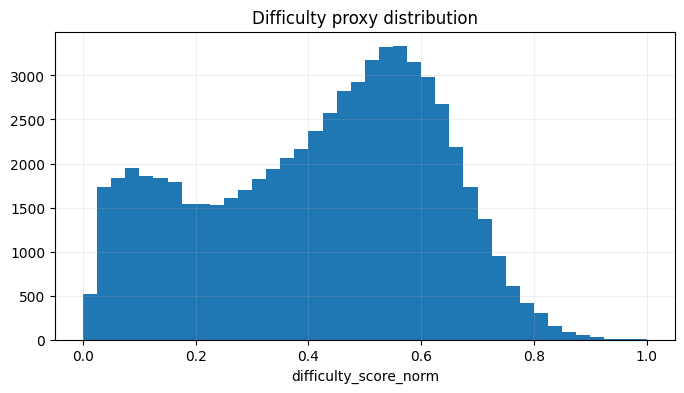

In [13]:
def make_difficulty_proxy(df):
    out = df.copy()

    out["difficulty_score"] = (
        0.4 * out["hr_est_std"].fillna(0.0) +
        0.3 * (1.0 - np.clip(out["ac_best"].fillna(0.0), 0.0, 1.0)) +
        0.3 * out["spectral_entropy"].fillna(0.0)
    )

    mn = out["difficulty_score"].min()
    mx = out["difficulty_score"].max()
    if mx > mn:
        out["difficulty_score_norm"] = (out["difficulty_score"] - mn) / (mx - mn)
    else:
        out["difficulty_score_norm"] = 0.0

    return out

analysis_df = make_difficulty_proxy(model_df)

display(analysis_df[[
    "difficulty_score", "difficulty_score_norm",
    "hr_ref", "ac_best", "hr_est_std", "spectral_entropy"
]].head())

plt.figure(figsize=(8, 4))
plt.hist(analysis_df["difficulty_score_norm"], bins=40)
plt.title("Difficulty proxy distribution")
plt.xlabel("difficulty_score_norm")
plt.grid(alpha=0.2)
plt.show()

In [14]:
if len(model_df) >= 50:
    X_all = model_df[feature_cols].astype(np.float32).values
    y_all = model_df["hr_ref"].values.astype(np.float32)
    groups_all = model_df["subject_id"].values

    X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

    gkf = GroupKFold(n_splits=5)
    rows_cv = []

    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups=groups_all), start=1):
        X_tr, X_te = X_all[tr_idx], X_all[te_idx]
        y_tr, y_te = y_all[tr_idx], y_all[te_idx]

        scaler_cv = StandardScaler()
        X_tr_sc = scaler_cv.fit_transform(X_tr)
        X_te_sc = scaler_cv.transform(X_te)

        reg_cv = RandomForestRegressor(
            n_estimators=300,
            random_state=SEED + fold,
            n_jobs=-1,
            min_samples_leaf=2,
        )
        reg_cv.fit(X_tr_sc, y_tr)
        pred_cv = reg_cv.predict(X_te_sc)

        rows_cv.append({
            "fold": fold,
            "mae": float(mean_absolute_error(y_te, pred_cv)),
            "rmse": float(np.sqrt(mean_squared_error(y_te, pred_cv))),
            "r2": float(r2_score(y_te, pred_cv)),
        })

    cv_df = pd.DataFrame(rows_cv)
    display(cv_df)
    print("=== Mean CV metrics ===")
    display(cv_df.mean(numeric_only=True))

,fold,mae,rmse,r2
0,1,8.565759,13.583039,0.649785
1,2,5.683691,9.063952,0.696484
2,3,10.398833,18.250562,0.555797
3,4,9.703494,14.653314,0.572010
4,5,7.639212,11.892287,0.603159


=== Mean CV metrics ===


fold     3.000000
mae      8.398198
rmse    13.488631
r2       0.615447
dtype: float64

In [15]:
if len(model_df) >= 50:
    groups = model_df["subject_id"].values
    y = model_df["hr_ref"].values.astype(np.float32)
    X = model_df[feature_cols].astype(np.float32).values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx_sched, test_idx_sched = next(splitter.split(X, y, groups=groups))

    test_sched = model_df.iloc[test_idx_sched].copy().reset_index(drop=True)

    scaler_sched = StandardScaler()
    X_train_sched_sc = scaler_sched.fit_transform(X[train_idx_sched])
    X_test_sched_sc = scaler_sched.transform(X[test_idx_sched])

    rf_sched = RandomForestRegressor(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        min_samples_leaf=2,
    )
    rf_sched.fit(X_train_sched_sc, y[train_idx_sched])
    test_sched["pred_hr"] = rf_sched.predict(X_test_sched_sc)

    test_sched = make_difficulty_proxy(test_sched)

    test_sched["difficulty_bin"] = pd.qcut(
        test_sched["difficulty_score_norm"], q=3, labels=["easy", "medium", "hard"]
    )

    keep_mask = np.zeros(len(test_sched), dtype=bool)

    easy_idx = test_sched.index[test_sched["difficulty_bin"] == "easy"].tolist()
    med_idx = test_sched.index[test_sched["difficulty_bin"] == "medium"].tolist()
    hard_idx = test_sched.index[test_sched["difficulty_bin"] == "hard"].tolist()

    keep_mask[easy_idx[::3]] = True
    keep_mask[med_idx[::2]] = True
    keep_mask[hard_idx] = True

    kept = test_sched[keep_mask].copy()

    full_mae = mean_absolute_error(test_sched["hr_ref"], test_sched["pred_hr"])
    kept_mae = mean_absolute_error(kept["hr_ref"], kept["pred_hr"])

    infer_ratio = len(kept) / len(test_sched)

    print("=== Offline scheduling simulation ===")
    print(f"Full inference windows : {len(test_sched)}")
    print(f"Kept inference windows : {len(kept)}")
    print(f"Inference ratio        : {infer_ratio:.4f}")
    print(f"Full MAE               : {full_mae:.4f}")
    print(f"Kept MAE               : {kept_mae:.4f}")

=== Offline scheduling simulation ===
Full inference windows : 11797
Kept inference windows : 7209
Inference ratio        : 0.6111
Full MAE               : 8.4491
Kept MAE               : 9.6776


Correlation(difficulty_score_norm, abs_error) = 0.34760987200358423


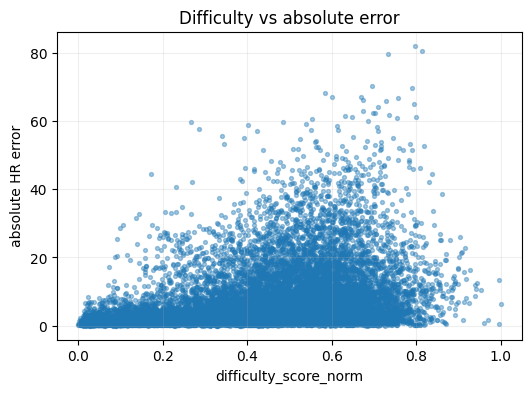

,count,mean,median,std
difficulty_bin,,,,
easy,3933,3.952850,2.025994,5.553746
medium,3932,9.821419,6.801977,9.469396
hard,3932,11.574088,7.941910,11.506606


In [16]:
if len(model_df) >= 50:
    groups = model_df["subject_id"].values
    y = model_df["hr_ref"].values.astype(np.float32)
    X = model_df[feature_cols].astype(np.float32).values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx_diff, test_idx_diff = next(splitter.split(X, y, groups=groups))

    test_view = model_df.iloc[test_idx_diff].copy().reset_index(drop=True)

    scaler_diff = StandardScaler()
    X_train_diff_sc = scaler_diff.fit_transform(X[train_idx_diff])
    X_test_diff_sc = scaler_diff.transform(X[test_idx_diff])

    rf_diff = RandomForestRegressor(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        min_samples_leaf=2,
    )
    rf_diff.fit(X_train_diff_sc, y[train_idx_diff])

    pred_test = rf_diff.predict(X_test_diff_sc)
    test_view["pred_hr"] = pred_test
    test_view["abs_error"] = np.abs(test_view["hr_ref"] - test_view["pred_hr"])

    test_view = make_difficulty_proxy(test_view)

    corr = test_view[["difficulty_score_norm", "abs_error"]].corr().iloc[0, 1]
    print("Correlation(difficulty_score_norm, abs_error) =", corr)

    plt.figure(figsize=(6, 4))
    plt.scatter(test_view["difficulty_score_norm"], test_view["abs_error"], s=8, alpha=0.4)
    plt.xlabel("difficulty_score_norm")
    plt.ylabel("absolute HR error")
    plt.title("Difficulty vs absolute error")
    plt.grid(alpha=0.2)
    plt.show()

    test_view["difficulty_bin"] = pd.qcut(
        test_view["difficulty_score_norm"], q=3, labels=["easy", "medium", "hard"]
    )

    bin_stats = test_view.groupby("difficulty_bin")["abs_error"].agg(["count", "mean", "median", "std"])
    display(bin_stats)

In [17]:
if len(model_df) >= 50:
    groups = model_df["subject_id"].values
    y = model_df["hr_ref"].values.astype(np.float32)
    X = model_df[feature_cols].astype(np.float32).values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx_cmp, test_idx_cmp = next(splitter.split(X, y, groups=groups))

    X_train_cmp, X_test_cmp = X[train_idx_cmp], X[test_idx_cmp]
    y_train_cmp, y_test_cmp = y[train_idx_cmp], y[test_idx_cmp]

    scaler_cmp = StandardScaler()
    X_train_cmp_sc = scaler_cmp.fit_transform(X_train_cmp)
    X_test_cmp_sc = scaler_cmp.transform(X_test_cmp)

    model_zoo = {
        "Ridge": Ridge(alpha=1.0),
        "MLP_small": MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=256,
            learning_rate_init=1e-3,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED,
        ),
        "RF": RandomForestRegressor(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1,
            min_samples_leaf=2,
        ),
    }

    compare_rows = []

    for name, model in model_zoo.items():
        model.fit(X_train_cmp_sc, y_train_cmp)
        pred_cmp = model.predict(X_test_cmp_sc)

        compare_rows.append({
            "model": name,
            "mae": float(mean_absolute_error(y_test_cmp, pred_cmp)),
            "rmse": float(np.sqrt(mean_squared_error(y_test_cmp, pred_cmp))),
            "r2": float(r2_score(y_test_cmp, pred_cmp)),
        })

    compare_df = pd.DataFrame(compare_rows).sort_values("mae", ascending=True).reset_index(drop=True)
    display(compare_df)

,model,mae,rmse,r2
0,MLP_small,8.375531,12.588931,0.717967
1,RF,8.449071,12.895291,0.704074
2,Ridge,9.595860,13.500854,0.675627


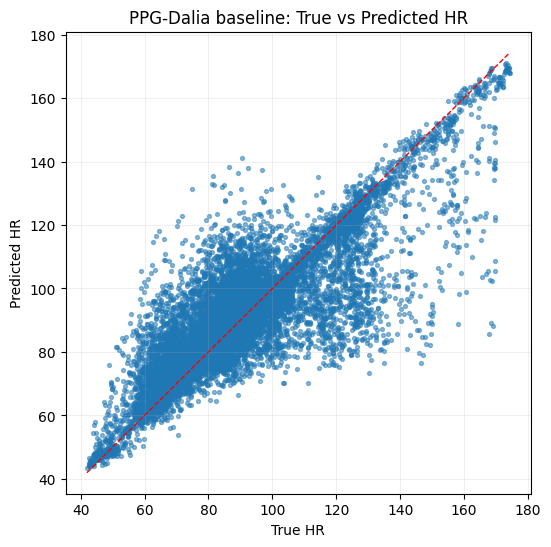

,feature,importance
7,peak_rate_per_sec,0.290664
6,n_peaks,0.281643
8,hr_est_mean,0.056439
12,ac_best_hr,0.054904
9,hr_est_std,0.052936
13,psd_hr_ratio,0.041892
0,mean,0.036351
11,ac_best,0.035599
14,spectral_entropy,0.027247
5,slope_abs_mean,0.024184


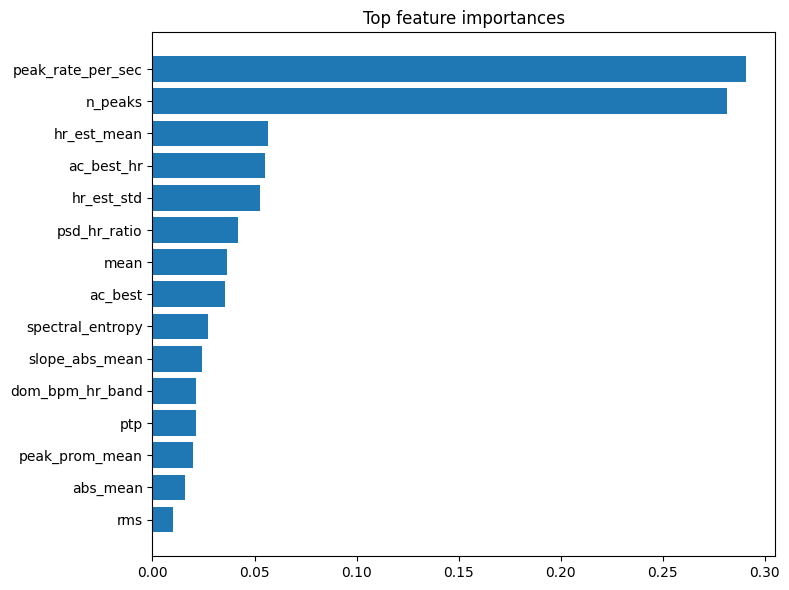

In [18]:
if len(model_df) >= 50:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred, s=8, alpha=0.5)
    lo = min(np.min(y_test), np.min(pred))
    hi = max(np.max(y_test), np.max(pred))
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    plt.xlabel("True HR")
    plt.ylabel("Predicted HR")
    plt.title("PPG-Dalia baseline: True vs Predicted HR")
    plt.grid(alpha=0.2)
    plt.show()

    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": reg.feature_importances_
    }).sort_values("importance", ascending=False)

    display(imp_df.head(20))

    plt.figure(figsize=(8, 6))
    topn = min(15, len(imp_df))
    plt.barh(imp_df["feature"].head(topn)[::-1], imp_df["importance"].head(topn)[::-1])
    plt.title("Top feature importances")
    plt.tight_layout()
    plt.show()

## TinyML track: MLP -> TFLite (FP32 + INT8)

Phần này mở rộng từ baseline feature-based hiện có để đi đúng hướng deployment trên ESP32S3:
- Train một MLP nhỏ bằng TensorFlow/Keras trên cùng `feature_cols`
- Export ra `TFLite` bản FP32 và INT8
- So sánh sai số `MAE/RMSE` giữa Keras và TFLite
- Xuất một tập mẫu feature INT8 để test nhanh firmware runtime

In [19]:
# TensorFlow availability check
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
    print("TensorFlow:", tf.__version__)
except Exception as e:
    HAS_TF = False
    print("⚠️ TensorFlow chưa sẵn sàng:", e)

TINYML_ARTIFACT_DIR = Path("./artifacts/ppg_dalia_tinyml")
TINYML_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if len(model_df) < 50:
    print("⚠️ Chưa đủ dữ liệu để train TinyML model")
elif not HAS_TF:
    print("⚠️ Bỏ qua TinyML track vì thiếu TensorFlow")
else:
    tinyml_df = model_df.copy().reset_index(drop=True)
    tinyml_feature_cols = feature_cols.copy()

    X_all = tinyml_df[tinyml_feature_cols].astype(np.float32).values
    y_all = tinyml_df["hr_ref"].astype(np.float32).values.reshape(-1, 1)
    groups_all = tinyml_df["subject_id"].values

    X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

    split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx, te_idx = next(split.split(X_all, y_all, groups=groups_all))

    X_train_raw, X_test_raw = X_all[tr_idx], X_all[te_idx]
    y_train, y_test_tiny = y_all[tr_idx], y_all[te_idx]

    tiny_scaler = StandardScaler()
    X_train = tiny_scaler.fit_transform(X_train_raw).astype(np.float32)
    X_test = tiny_scaler.transform(X_test_raw).astype(np.float32)

    print("TinyML split:", X_train.shape, X_test.shape)
    print("Feature dim:", X_train.shape[1])

TensorFlow: 2.20.0
TinyML split: (52900, 16) (11797, 16)
Feature dim: 16


TinyML split (group-aware):
  Fit : (43968, 16) | subjects = ['S10', 'S11', 'S12', 'S14', 'S15', 'S2', 'S5', 'S7', 'S8', 'S9']
  Val : (8932, 16) | subjects = ['S13', 'S3']
  Test: (11797, 16) | subjects = ['S1', 'S4', 'S6']

Iteration 1: baseline_64_32 | params=3201 | epochs=86 | train_mae=7.7024 | val_mae=4.9546 | gap=-2.7477
Iteration 2: mlp_128_128_64_do015 | params=27009 | epochs=94 | train_mae=7.1920 | val_mae=4.6892 | gap=-2.5029
Iteration 3: mlp_192_128_64_do020 | params=36289 | epochs=92 | train_mae=7.2547 | val_mae=4.6383 | gap=-2.6164
Iteration 4: mlp_256_128_64_do025 | params=45569 | epochs=150 | train_mae=7.2746 | val_mae=4.6444 | gap=-2.6302
Iteration 5: mlp_128_128_64_32_do020 | params=29057 | epochs=63 | train_mae=7.8431 | val_mae=4.8234 | gap=-3.0197


,iteration,name,layers,dropout,l2,lr,params,epochs_run,best_epoch,train_mae,val_mae,val_rmse,overfit_gap,selection_score
0,3,mlp_192_128_64_do020,192-128-64,0.20,0.0001,0.0008,36289,92,67,7.254704,4.638257,7.716414,-2.616446,4.641886
1,4,mlp_256_128_64_do025,256-128-64,0.25,0.0002,0.0007,45569,150,125,7.274617,4.644403,7.742295,-2.630214,4.648960
2,2,mlp_128_128_64_do015,128-128-64,0.15,0.0001,0.0010,27009,94,69,7.192035,4.689166,7.797081,-2.502869,4.691866
3,5,mlp_128_128_64_32_do020,128-128-64-32,0.20,0.0001,0.0008,29057,63,38,7.843149,4.823435,7.801128,-3.019714,4.826341
4,1,baseline_64_32,64-32,0.00,0.0000,0.0010,3201,86,61,7.702353,4.954623,7.930071,-2.747730,4.954943


=== Selected TinyML Keras MLP ===
{'name': 'mlp_192_128_64_do020', 'layers': [192, 128, 64], 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.0008, 'batch_size': 128, 'huber_delta': 1.0}
Validation MAE=4.6383 | Test MAE=8.1217, RMSE=12.6226, R2=0.7165


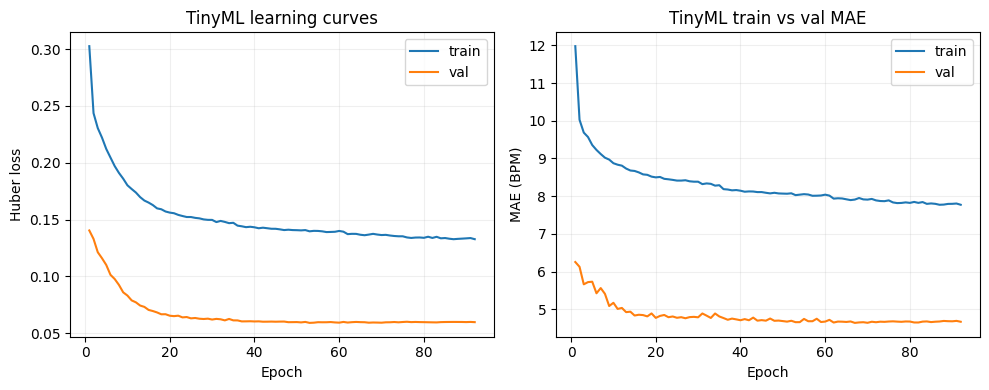

INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpakts4bi7\assets


INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpakts4bi7\assets


Saved artifact at 'C:\Users\nguye\AppData\Local\Temp\tmpakts4bi7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16), dtype=tf.float32, name='ppg_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1992735526352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1992735524816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1992735526928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620467792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620471632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620476816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620475856: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpytfrsmh3\assets


INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpytfrsmh3\assets


Saved artifact at 'C:\Users\nguye\AppData\Local\Temp\tmpytfrsmh3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16), dtype=tf.float32, name='ppg_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1992735526352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1992735524816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1992735526928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620467792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620471632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620476816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1990620475856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: artifacts\ppg_dalia_tinyml\ppg_hr_mlp.keras
Saved: artifacts\ppg_dalia_tinyml\ppg_hr_mlp_fp32.tflite | size(bytes)= 147540
Saved: artifacts\ppg_d

In [20]:
if len(model_df) >= 50 and HAS_TF:
    import gc

    def build_tinyml_mlp(input_dim: int, config: dict):
        reg = keras.regularizers.l2(float(config.get("l2", 0.0)))
        inputs = keras.Input(shape=(input_dim,), name="ppg_features")
        x = inputs
        for idx, units in enumerate(config["layers"], start=1):
            x = layers.Dense(
                units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=reg,
                name=f"dense_{idx}",
            )(x)
            dropout_rate = float(config.get("dropout", 0.0))
            if dropout_rate > 0.0:
                x = layers.Dropout(dropout_rate, name=f"dropout_{idx}")(x)

        outputs = layers.Dense(1, activation="linear", name="hr_pred_norm")(x)
        model = keras.Model(inputs=inputs, outputs=outputs, name=config["name"])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=float(config.get("lr", 1e-3))),
            loss=keras.losses.Huber(delta=float(config.get("huber_delta", 1.0))),
            metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
        )
        return model

    def denorm_hr(y_norm: np.ndarray, mean: float, std: float) -> np.ndarray:
        return (np.asarray(y_norm, dtype=np.float32).reshape(-1) * std + mean).astype(np.float32)

    y_train_full_vec = y_train.reshape(-1).astype(np.float32)
    y_test_vec = y_test_tiny.reshape(-1).astype(np.float32)
    train_groups_all = groups_all[tr_idx]

    split_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED + 11)
    fit_idx, val_idx = next(split_val.split(X_train_raw, y_train_full_vec, groups=train_groups_all))

    X_fit_raw, X_val_raw = X_train_raw[fit_idx], X_train_raw[val_idx]
    y_fit_vec, y_val_vec = y_train_full_vec[fit_idx], y_train_full_vec[val_idx]
    groups_fit, groups_val = train_groups_all[fit_idx], train_groups_all[val_idx]

    tiny_scaler = StandardScaler()
    X_fit = tiny_scaler.fit_transform(X_fit_raw).astype(np.float32)
    X_val = tiny_scaler.transform(X_val_raw).astype(np.float32)
    X_test = tiny_scaler.transform(X_test_raw).astype(np.float32)
    X_train = X_fit
    y_train_vec = y_fit_vec.copy()

    hr_mean = float(np.mean(y_fit_vec))
    hr_std = float(np.std(y_fit_vec) + 1e-6)

    y_fit_norm = ((y_fit_vec - hr_mean) / hr_std).astype(np.float32).reshape(-1, 1)
    y_val_norm = ((y_val_vec - hr_mean) / hr_std).astype(np.float32).reshape(-1, 1)
    y_test_norm = ((y_test_vec - hr_mean) / hr_std).astype(np.float32)

    print("TinyML split (group-aware):")
    print("  Fit :", X_fit.shape, "| subjects =", np.unique(groups_fit).tolist())
    print("  Val :", X_val.shape, "| subjects =", np.unique(groups_val).tolist())
    print("  Test:", X_test.shape, "| subjects =", np.unique(groups_all[te_idx]).tolist())

    candidate_configs = [
        {
            "name": "baseline_64_32",
            "layers": [64, 32],
            "dropout": 0.00,
            "l2": 0.0,
            "lr": 1.0e-3,
            "batch_size": 128,
            "huber_delta": 1.0,
        },
        {
            "name": "mlp_128_128_64_do015",
            "layers": [128, 128, 64],
            "dropout": 0.15,
            "l2": 1.0e-4,
            "lr": 1.0e-3,
            "batch_size": 128,
            "huber_delta": 1.0,
        },
        {
            "name": "mlp_192_128_64_do020",
            "layers": [192, 128, 64],
            "dropout": 0.20,
            "l2": 1.0e-4,
            "lr": 8.0e-4,
            "batch_size": 128,
            "huber_delta": 1.0,
        },
        {
            "name": "mlp_256_128_64_do025",
            "layers": [256, 128, 64],
            "dropout": 0.25,
            "l2": 2.0e-4,
            "lr": 7.0e-4,
            "batch_size": 128,
            "huber_delta": 1.0,
        },
        {
            "name": "mlp_128_128_64_32_do020",
            "layers": [128, 128, 64, 32],
            "dropout": 0.20,
            "l2": 1.0e-4,
            "lr": 8.0e-4,
            "batch_size": 128,
            "huber_delta": 1.0,
        },
    ]

    candidate_results = []
    best_bundle = None

    def run_candidate(config: dict, iteration: int):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED + iteration)

        model = build_tinyml_mlp(X_fit.shape[1], config)
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_mae",
                patience=25,
                mode="min",
                restore_best_weights=True,
                verbose=0,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_mae",
                factor=0.5,
                patience=8,
                min_lr=1.0e-5,
                verbose=0,
            ),
        ]

        history = model.fit(
            X_fit,
            y_fit_norm,
            validation_data=(X_val, y_val_norm),
            epochs=250,
            batch_size=int(config.get("batch_size", 128)),
            verbose=0,
            callbacks=callbacks,
        )

        fit_pred = denorm_hr(model.predict(X_fit, verbose=0), hr_mean, hr_std)
        val_pred = denorm_hr(model.predict(X_val, verbose=0), hr_mean, hr_std)

        train_mae = float(mean_absolute_error(y_fit_vec, fit_pred))
        val_mae = float(mean_absolute_error(y_val_vec, val_pred))
        val_rmse = float(np.sqrt(mean_squared_error(y_val_vec, val_pred)))
        overfit_gap = float(val_mae - train_mae)
        epochs_run = int(len(history.history["loss"]))
        best_epoch = int(np.argmin(history.history["val_mae"]) + 1)
        params = int(model.count_params())
        selection_score = float(val_mae + max(0.0, overfit_gap - 1.0) * 0.25 + params / 1.0e7)

        result = {
            "iteration": iteration,
            "name": config["name"],
            "layers": "-".join(str(x) for x in config["layers"]),
            "dropout": float(config.get("dropout", 0.0)),
            "l2": float(config.get("l2", 0.0)),
            "lr": float(config.get("lr", 1.0e-3)),
            "params": params,
            "epochs_run": epochs_run,
            "best_epoch": best_epoch,
            "train_mae": train_mae,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "overfit_gap": overfit_gap,
            "selection_score": selection_score,
        }

        print(
            f"Iteration {iteration}: {config['name']} | params={params} | "
            f"epochs={epochs_run} | train_mae={train_mae:.4f} | "
            f"val_mae={val_mae:.4f} | gap={overfit_gap:.4f}"
        )

        bundle = {
            "config": dict(config),
            "weights": model.get_weights(),
            "history": {k: list(v) for k, v in history.history.items()},
            "result": result,
        }

        del model
        gc.collect()
        return result, bundle

    iteration = 1
    for config in candidate_configs:
        result, bundle = run_candidate(config, iteration)
        candidate_results.append(result)
        if best_bundle is None or result["selection_score"] < best_bundle["result"]["selection_score"]:
            best_bundle = bundle
        iteration += 1

    if best_bundle["result"]["val_mae"] > 7.0:
        print("Validation MAE still above target. Launching stage-2 wider models...")
        stage2_configs = [
            {
                "name": "stage2_256_192_96_do030",
                "layers": [256, 192, 96],
                "dropout": 0.30,
                "l2": 2.0e-4,
                "lr": 5.0e-4,
                "batch_size": 96,
                "huber_delta": 1.0,
            },
            {
                "name": "stage2_192_192_128_64_do025",
                "layers": [192, 192, 128, 64],
                "dropout": 0.25,
                "l2": 1.0e-4,
                "lr": 6.0e-4,
                "batch_size": 96,
                "huber_delta": 1.0,
            },
        ]
        for config in stage2_configs:
            result, bundle = run_candidate(config, iteration)
            candidate_results.append(result)
            if result["selection_score"] < best_bundle["result"]["selection_score"]:
                best_bundle = bundle
            iteration += 1

    tinyml_candidates_df = pd.DataFrame(candidate_results).sort_values(
        ["selection_score", "val_mae", "params"], ascending=[True, True, True]
    ).reset_index(drop=True)
    display(tinyml_candidates_df)

    best_config = best_bundle["config"]
    best_result = best_bundle["result"]
    tinyml_model = build_tinyml_mlp(X_fit.shape[1], best_config)
    tinyml_model.set_weights(best_bundle["weights"])
    tinyml_history = best_bundle["history"]

    keras_pred_norm = tinyml_model.predict(X_test, verbose=0).reshape(-1)
    keras_pred = denorm_hr(keras_pred_norm, hr_mean, hr_std)

    keras_mae = float(mean_absolute_error(y_test_vec, keras_pred))
    keras_rmse = float(np.sqrt(mean_squared_error(y_test_vec, keras_pred)))
    keras_r2 = float(r2_score(y_test_vec, keras_pred))

    print("=== Selected TinyML Keras MLP ===")
    print(best_config)
    print(
        f"Validation MAE={best_result['val_mae']:.4f} | "
        f"Test MAE={keras_mae:.4f}, RMSE={keras_rmse:.4f}, R2={keras_r2:.4f}"
    )

    hist_df = pd.DataFrame(tinyml_history)
    hist_df["epoch"] = np.arange(1, len(hist_df) + 1)
    hist_df["train_mae_bpm"] = hist_df["mae"] * hr_std
    hist_df["val_mae_bpm"] = hist_df["val_mae"] * hr_std
    tinyml_history_df = hist_df.copy()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist_df["epoch"], hist_df["loss"], label="train")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Huber loss")
    plt.title("TinyML learning curves")
    plt.grid(alpha=0.2)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist_df["epoch"], hist_df["train_mae_bpm"], label="train")
    plt.plot(hist_df["epoch"], hist_df["val_mae_bpm"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("MAE (BPM)")
    plt.title("TinyML train vs val MAE")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    tinyml_model_path = TINYML_ARTIFACT_DIR / "ppg_hr_mlp.keras"
    tinyml_model.save(tinyml_model_path)

    converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(tinyml_model)
    tflite_fp32 = converter_fp32.convert()
    tflite_fp32_path = TINYML_ARTIFACT_DIR / "ppg_hr_mlp_fp32.tflite"
    tflite_fp32_path.write_bytes(tflite_fp32)

    def representative_dataset():
        n_rep = min(512, len(X_fit))
        idx = np.linspace(0, len(X_fit) - 1, n_rep, dtype=int)
        for i in idx:
            yield [X_fit[i:i+1].astype(np.float32)]

    converter_int8 = tf.lite.TFLiteConverter.from_keras_model(tinyml_model)
    converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_int8.representative_dataset = representative_dataset
    converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_int8.inference_input_type = tf.int8
    converter_int8.inference_output_type = tf.int8
    tflite_int8 = converter_int8.convert()
    tflite_int8_path = TINYML_ARTIFACT_DIR / "ppg_hr_mlp_int8.tflite"
    tflite_int8_path.write_bytes(tflite_int8)

    target_norm_meta = {
        "hr_mean": hr_mean,
        "hr_std": hr_std,
        "best_config": best_config,
        "validation_mae": best_result["val_mae"],
        "test_mae": keras_mae,
    }

    with open(TINYML_ARTIFACT_DIR / "tinyml_feature_columns.json", "w", encoding="utf-8") as f:
        json.dump(tinyml_feature_cols, f, ensure_ascii=False, indent=2)

    with open(TINYML_ARTIFACT_DIR / "tinyml_scaler.pkl", "wb") as f:
        pickle.dump(tiny_scaler, f)

    with open(TINYML_ARTIFACT_DIR / "tinyml_target_norm.json", "w", encoding="utf-8") as f:
        json.dump(target_norm_meta, f, ensure_ascii=False, indent=2)

    tinyml_candidates_df.to_csv(TINYML_ARTIFACT_DIR / "tinyml_candidate_results.csv", index=False)
    tinyml_history_df.to_csv(TINYML_ARTIFACT_DIR / "tinyml_best_history.csv", index=False)

    print("Saved:", tinyml_model_path)
    print("Saved:", tflite_fp32_path, "| size(bytes)=", tflite_fp32_path.stat().st_size)
    print("Saved:", tflite_int8_path, "| size(bytes)=", tflite_int8_path.stat().st_size)
    print("Saved:", TINYML_ARTIFACT_DIR / "tinyml_candidate_results.csv")
    print("Saved:", TINYML_ARTIFACT_DIR / "tinyml_best_history.csv")
    print("Saved:", TINYML_ARTIFACT_DIR / "tinyml_target_norm.json")

In [21]:
if len(model_df) >= 50 and HAS_TF:
    def tflite_predict_regression(model_path: Path, x_float: np.ndarray):
        interpreter = tf.lite.Interpreter(model_path=str(model_path))
        interpreter.allocate_tensors()

        in_detail = interpreter.get_input_details()[0]
        out_detail = interpreter.get_output_details()[0]

        in_idx = in_detail["index"]
        out_idx = out_detail["index"]

        in_dtype = in_detail["dtype"]
        out_dtype = out_detail["dtype"]

        in_scale, in_zero = in_detail.get("quantization", (0.0, 0))
        out_scale, out_zero = out_detail.get("quantization", (0.0, 0))

        preds = []
        for i in range(len(x_float)):
            x = x_float[i:i+1].astype(np.float32)
            if in_dtype == np.int8:
                x_q = np.clip(np.round(x / in_scale + in_zero), -128, 127).astype(np.int8)
                interpreter.set_tensor(in_idx, x_q)
            else:
                interpreter.set_tensor(in_idx, x.astype(in_dtype))

            interpreter.invoke()
            y = interpreter.get_tensor(out_idx)

            if out_dtype == np.int8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            preds.append(float(y.reshape(-1)[0]))

        return np.asarray(preds, dtype=np.float32), {
            "input_dtype": str(in_dtype),
            "output_dtype": str(out_dtype),
            "in_quant": (float(in_scale), int(in_zero)),
            "out_quant": (float(out_scale), int(out_zero)),
        }

    pred_fp32_norm, info_fp32 = tflite_predict_regression(tflite_fp32_path, X_test)
    pred_int8_norm, info_int8 = tflite_predict_regression(tflite_int8_path, X_test)

    pred_fp32 = (pred_fp32_norm * hr_std + hr_mean).astype(np.float32)
    pred_int8 = (pred_int8_norm * hr_std + hr_mean).astype(np.float32)

    fp32_mae = float(mean_absolute_error(y_test_vec, pred_fp32))
    fp32_rmse = float(np.sqrt(mean_squared_error(y_test_vec, pred_fp32)))

    int8_mae = float(mean_absolute_error(y_test_vec, pred_int8))
    int8_rmse = float(np.sqrt(mean_squared_error(y_test_vec, pred_int8)))

    compare_tinyml = pd.DataFrame([
        {
            "model": "Keras_MLP",
            "val_mae": best_result["val_mae"],
            "test_mae": keras_mae,
            "test_rmse": keras_rmse,
        },
        {
            "model": "TFLite_FP32",
            "val_mae": np.nan,
            "test_mae": fp32_mae,
            "test_rmse": fp32_rmse,
        },
        {
            "model": "TFLite_INT8",
            "val_mae": np.nan,
            "test_mae": int8_mae,
            "test_rmse": int8_rmse,
        },
    ])

    print("=== TinyML model comparison (denorm HR) ===")
    display(compare_tinyml)

    print("FP32 IO info:", info_fp32)
    print("INT8 IO info:", info_int8)

    size_fp32 = tflite_fp32_path.stat().st_size
    size_int8 = tflite_int8_path.stat().st_size
    print(f"Size FP32: {size_fp32/1024:.2f} KB")
    print(f"Size INT8: {size_int8/1024:.2f} KB")
    print(f"Compression ratio FP32/INT8: {size_fp32/max(size_int8,1):.3f}")

    n_export = min(16, len(X_test))
    x_export = X_test[:n_export]
    y_export = y_test_vec[:n_export]

    in_scale, in_zero = info_int8["in_quant"]
    x_export_q = np.clip(np.round(x_export / in_scale + in_zero), -128, 127).astype(np.int8)

    np.save(TINYML_ARTIFACT_DIR / "tinyml_x_test_fp32.npy", x_export.astype(np.float32))
    np.save(TINYML_ARTIFACT_DIR / "tinyml_x_test_int8.npy", x_export_q)
    np.save(TINYML_ARTIFACT_DIR / "tinyml_y_test.npy", y_export.astype(np.float32))
    compare_tinyml.to_csv(TINYML_ARTIFACT_DIR / "tinyml_model_compare.csv", index=False)

    print("Saved test vectors (.npy) in:", TINYML_ARTIFACT_DIR.resolve())
    print("Saved:", TINYML_ARTIFACT_DIR / "tinyml_model_compare.csv")

=== TinyML model comparison (denorm HR) ===


,model,val_mae,test_mae,test_rmse
0,Keras_MLP,4.638257,8.121708,12.622576
1,TFLite_FP32,NaN,8.121708,12.622576
2,TFLite_INT8,NaN,8.111054,12.606258


FP32 IO info: {'input_dtype': "<class 'numpy.float32'>", 'output_dtype': "<class 'numpy.float32'>", 'in_quant': (0.0, 0), 'out_quant': (0.0, 0)}
INT8 IO info: {'input_dtype': "<class 'numpy.int8'>", 'output_dtype': "<class 'numpy.int8'>", 'in_quant': (0.06454043090343475, -52), 'out_quant': (0.022459285333752632, -37)}
Size FP32: 144.08 KB
Size INT8: 48.22 KB
Compression ratio FP32/INT8: 2.988
Saved test vectors (.npy) in: C:\ml\kaggle-ml-basics\artifacts\ppg_dalia_tinyml
Saved: artifacts\ppg_dalia_tinyml\tinyml_model_compare.csv


In [22]:
ARTIFACT_DIR = Path("./artifacts/ppg_dalia_feature_baseline")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

feature_df.to_csv(ARTIFACT_DIR / "feature_table.csv", index=False)
with open(ARTIFACT_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

if "scaler" in globals() and "reg" in globals() and len(model_df) >= 50:
    import joblib
    joblib.dump(scaler, ARTIFACT_DIR / "scaler.joblib")
    joblib.dump(reg, ARTIFACT_DIR / "rf_hr_regressor.joblib")

print("✅ Saved artifacts to:", ARTIFACT_DIR.resolve())

✅ Saved artifacts to: C:\ml\kaggle-ml-basics\artifacts\ppg_dalia_feature_baseline


In [23]:
if len(model_df) >= 50 and HAS_TF:
    def write_c_array_files(tflite_path: Path, header_path: Path, source_path: Path, var_name: str):
        data = tflite_path.read_bytes()
        guard = header_path.name.replace(".", "_").upper()
        header_text = "\n".join([
            f"#ifndef {guard}",
            f"#define {guard}",
            "",
            "#ifdef __cplusplus",
            'extern "C" {',
            "#endif",
            "",
            f"extern const unsigned char {var_name}[];",
            f"extern const unsigned int {var_name}_len;",
            "",
            "#ifdef __cplusplus",
            "}",
            "#endif",
            "",
            f"#endif  // {guard}",
            "",
        ])

        lines = []
        for start in range(0, len(data), 12):
            chunk = data[start:start + 12]
            lines.append("  " + ", ".join(f"0x{byte:02x}" for byte in chunk) + ",")

        source_text = "\n".join([
            f'#include "{header_path.name}"',
            "",
            f"const unsigned char {var_name}[] = {{",
            *lines,
            "};",
            "",
            f"const unsigned int {var_name}_len = {len(data)};",
            "",
        ])

        header_path.write_text(header_text, encoding="ascii", newline="\n")
        source_path.write_text(source_text, encoding="ascii", newline="\n")

    int8_header_path = TINYML_ARTIFACT_DIR / "ppg_hr_mlp_int8.h"
    int8_source_path = TINYML_ARTIFACT_DIR / "ppg_hr_mlp_int8.c"
    write_c_array_files(
        tflite_int8_path,
        int8_header_path,
        int8_source_path,
        "ppg_hr_mlp_int8_tflite",
    )

    tiny_scaler_export = {
        "feature_mean": tiny_scaler.mean_.tolist(),
        "feature_scale": tiny_scaler.scale_.tolist(),
        "target_mean": hr_mean,
        "target_std": hr_std,
    }
    with open(TINYML_ARTIFACT_DIR / "tinyml_scaler_export.json", "w", encoding="utf-8") as f:
        json.dump(tiny_scaler_export, f, ensure_ascii=False, indent=2)

    print("const float kScalerMean[16] = {", ", ".join([f"{x:.9f}f" for x in tiny_scaler.mean_]), "};")
    print("const float kScalerScale[16] = {", ", ".join([f"{x:.9f}f" for x in tiny_scaler.scale_]), "};")
    print(f"const float kHrMeanBpm = {hr_mean:.9f}f;")
    print(f"const float kHrStdBpm = {hr_std:.9f}f;")
    print("Saved:", int8_header_path)
    print("Saved:", int8_source_path)
    print("Saved:", TINYML_ARTIFACT_DIR / "tinyml_scaler_export.json")

const float kScalerMean[16] = { -0.072833283f, 1.185520255f, 6.942984485f, 1.194183326f, 0.884536889f, 0.145003450f, 12.239128457f, 1.529891057f, 98.692038757f, 24.175290967f, 2.636997192f, 0.472570512f, 67.527535489f, 0.905860722f, 0.413099367f, 79.423785480f };
const float kScalerScale[16] = { 0.117981490f, 0.475501781f, 4.919955321f, 0.474036623f, 0.202465910f, 0.039660174f, 2.298363264f, 0.287295408f, 19.044338531f, 11.633750699f, 0.662657755f, 0.211964997f, 16.674974307f, 0.055595740f, 0.062359681f, 22.796758519f };
const float kHrMeanBpm = 89.397438049f;
const float kHrStdBpm = 23.228986740f;
Saved: artifacts\ppg_dalia_tinyml\ppg_hr_mlp_int8.h
Saved: artifacts\ppg_dalia_tinyml\ppg_hr_mlp_int8.c
Saved: artifacts\ppg_dalia_tinyml\tinyml_scaler_export.json
